## 1- EDA

### load the laptop data

In [260]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv("laptopData.csv")
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


### Now check the data type and the and diplicates Rows

In [261]:
df.info()
df.duplicated().sum()


#delate the diplicates Rows
df=df.drop_duplicates()
df.duplicated().sum()  # We delete it



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1273 non-null   float64
 1   Company           1273 non-null   object 
 2   TypeName          1273 non-null   object 
 3   Inches            1273 non-null   object 
 4   ScreenResolution  1273 non-null   object 
 5   Cpu               1273 non-null   object 
 6   Ram               1273 non-null   object 
 7   Memory            1273 non-null   object 
 8   Gpu               1273 non-null   object 
 9   OpSys             1273 non-null   object 
 10  Weight            1273 non-null   object 
 11  Price             1273 non-null   float64
dtypes: float64(2), object(10)
memory usage: 122.3+ KB


np.int64(0)

In [262]:
#delate the diplicates Rows
df=df.drop_duplicates()
df.duplicated().sum()  # We delete it


np.int64(0)

### Check Missing values

In [263]:
df.isna().sum()

df[df.isna().any(axis=1)]  # من الواضح ان الصف رقم 20 هو  الفارغ فيحذف

df.dropna(how="all",inplace=True)  # تم حذف الصف

### Now check and change data type


In [264]:
# Frist we deleta GB Word and kg before we change the type
df["Ram"] = df["Ram"].str.replace('GB', "", case=False).astype(int)  # غيرت النوع الى int

df['Weight'] = df['Weight'].astype(str).str.replace('kg', '', case=False)
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')

df["Inches"]=pd.to_numeric(df["Inches"],errors='coerce')

df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080


### delete Unnamed Col


In [265]:
df.drop(columns="Unnamed: 0",inplace=True,errors="ignore")

df.head()




,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080


### Check outliers

In [266]:
df.describe()



,Inches,Ram,Weight,Price
count,1272.000000,1273.000000,1272.000000,1273.000000
mean,15.130818,8.462687,2.077618,59955.814073
std,1.954436,5.564408,0.807808,37332.251005
min,10.100000,1.000000,0.000200,9270.720000
25%,14.000000,4.000000,1.500000,31914.720000
50%,15.600000,8.000000,2.040000,52161.120000
75%,15.600000,8.000000,2.320000,79333.387200
max,35.600000,64.000000,11.100000,324954.720000


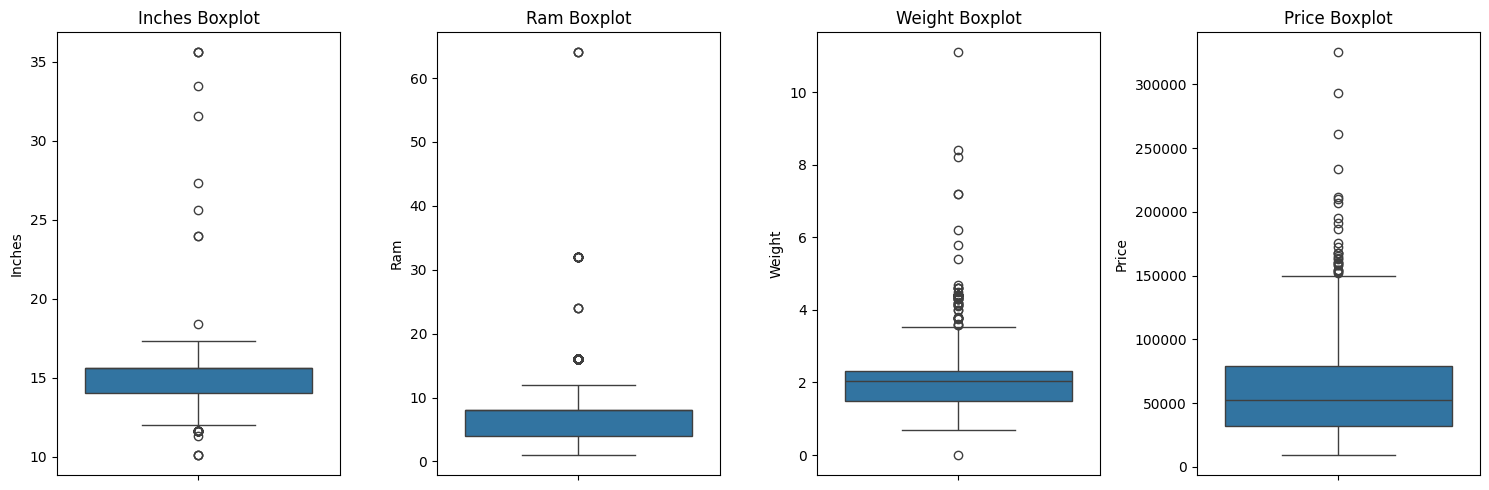

In [267]:
plt.figure(figsize=(15, 5))

for i, col in enumerate(['Inches', 'Ram', 'Weight', 'Price'], 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df[col])
    plt.title(f'{col} Boxplot')

plt.tight_layout()
plt.show()

#### نلاحظ ان هناك قسم الانش غير منطقية حيث انها تصل الى 35 وعددها قليل فبحذفها لانها ما راح تأثر

In [268]:
df=df[df["Inches"]<= 20]   # حذفت الاحجام الاكبر من 20



#### بما ان في عامود الذاكرة في نوعين SSD and HDD بنقلها الى عامود جديد يسهل الفهم

In [269]:
df['Memory'] = df['Memory'].astype(str).str.replace('1.0TB', '1000').astype(str).str.replace('1TB', '1000').str.replace('2TB', '2000').str.replace('GB', '')

def extract_ssd(text):
    words = str(text).split() 
    if 'SSD' in words:
        idx = words.index('SSD') 
        return int(words[idx-1]) 
    return 0 

df['SSD'] = df['Memory'].apply(extract_ssd)


def extract_hdd(text):
    words = str(text).split() 
    if 'HDD' in words:
        idx = words.index('HDD') 
        return int(words[idx-1]) 
    return 0 

df['HDD'] = df['Memory'].apply(extract_hdd)

df.head()


,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,SSD,HDD
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,128,0
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256 SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,256,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,512,0
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,256,0


### features engenering 

#### الحين بعدل في اعمدة المعالج وكرت الشاشة ونوع نظام التشغيل ليسهل للنموذج فهمها وتبسيطها

In [270]:
def get_cpu_brand(text):
    words = str(text).split()        #  نفصل النص إلى كلمات ليسهل للمودل الفهم
    brand = " ".join(words[0:3])    
    return brand                     

df['Cpu_Brand'] = df['Cpu'].apply(get_cpu_brand)

def get_gpu_brand(text):
    words = str(text).split()        
    brand = words[0]                
    return brand                     

df['Gpu_Brand'] = df['Gpu'].apply(get_gpu_brand)

def check_touchscreen(text):
    text = str(text).lower()         #  بحول النص لحروف صغيرة عشان البحث يكون دقيق ويلقطه
    if 'touchscreen' in text:
        return 1                    
    else:
        return 0                     

df['Touchscreen'] = df['ScreenResolution'].apply(check_touchscreen)

def categorize_os(os_name):
    text = str(os_name).lower()
    if 'windows' in text:
        return 'Windows'
    elif 'mac' in text:
        return 'Mac'
    elif 'linux' in text:
        return 'Linux'
    else:
        return 'No OS'

# تطبيق الدالة
df['OpSys'] = df['OpSys'].apply(categorize_os)

df.drop(columns=["Gpu","Cpu","ScreenResolution"],inplace=True,errors="ignore")

df.head()

,Company,TypeName,Inches,Ram,Memory,OpSys,Weight,Price,SSD,HDD,Cpu_Brand,Gpu_Brand,Touchscreen
0,Apple,Ultrabook,13.3,8,128 SSD,Mac,1.37,71378.6832,128,0,Intel Core i5,Intel,0
1,Apple,Ultrabook,13.3,8,128 Flash Storage,Mac,1.34,47895.5232,0,0,Intel Core i5,Intel,0
2,HP,Notebook,15.6,8,256 SSD,No OS,1.86,30636.0000,256,0,Intel Core i5,Intel,0
3,Apple,Ultrabook,15.4,16,512 SSD,Mac,1.83,135195.3360,512,0,Intel Core i7,AMD,0
4,Apple,Ultrabook,13.3,8,256 SSD,Mac,1.37,96095.8080,256,0,Intel Core i5,Intel,0


### الحين بسوي encodeing

In [271]:
text_column = ['Company', 'TypeName', 'Cpu_Brand', 'Gpu_Brand', 'OpSys']

df_New=pd.get_dummies(df,columns=text_column,drop_first=True,dtype=int)

df_New.head()

,Inches,Ram,Memory,Weight,Price,SSD,HDD,Touchscreen,Company_Apple,Company_Asus,...,Cpu_Brand_Intel Pentium Quad,Cpu_Brand_Intel Xeon E3-1505M,Cpu_Brand_Intel Xeon E3-1535M,Cpu_Brand_Samsung Cortex A72&A53,Gpu_Brand_ARM,Gpu_Brand_Intel,Gpu_Brand_Nvidia,OpSys_Mac,OpSys_No OS,OpSys_Windows
0,13.3,8,128 SSD,1.37,71378.6832,128,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,13.3,8,128 Flash Storage,1.34,47895.5232,0,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
2,15.6,8,256 SSD,1.86,30636.0000,256,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
3,15.4,16,512 SSD,1.83,135195.3360,512,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
4,13.3,8,256 SSD,1.37,96095.8080,256,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0


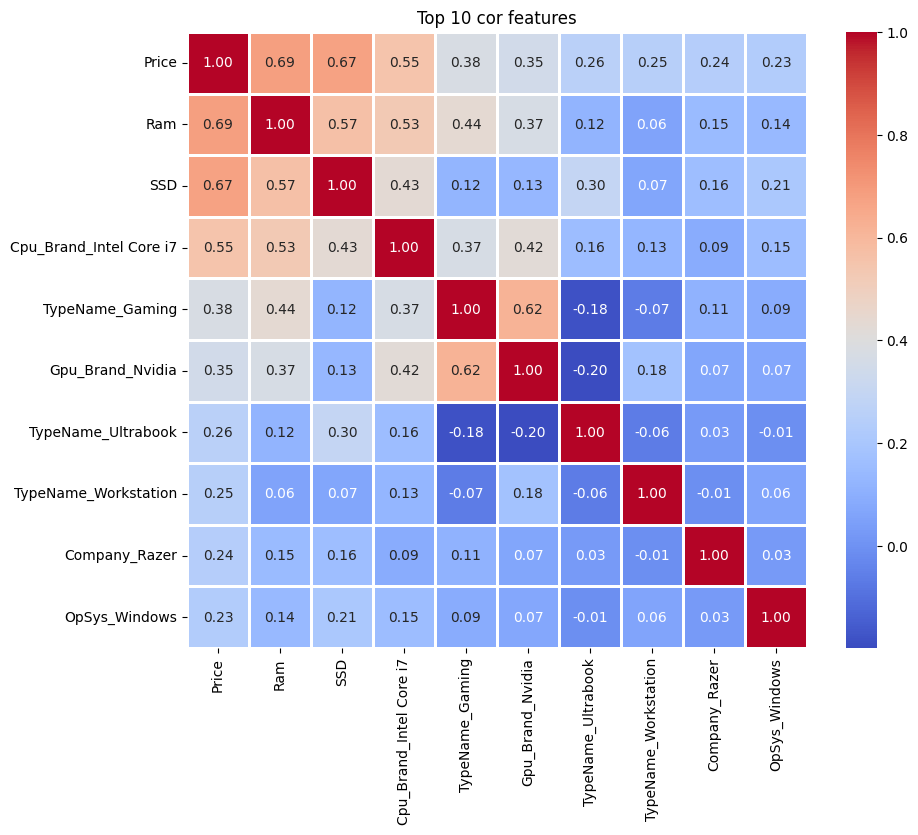

In [272]:
top_10_cols = df_New.corr(numeric_only=True)['Price'].sort_values(ascending=False).head(10).index
# 2. تحديد حجم مناسب للرسمة
plt.figure(figsize=(10, 8))

sns.heatmap(df_New[top_10_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=1)

plt.title("Top 10 cor features")
plt.show()

#### من الواضخ ان هناك ارتباط جيد جدا بين السعر و نوع الذاكرة العشوائية وايضا السعر مع ذاكرة التخزين وايضا الذاكره العشوائية مساحة التخزين SSD

### 2.ML

In [276]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # (اختياري) لتسوية البيانات إذا احتجت لذلك
from sklearn.linear_model import LinearRegression    # الموديل الخطي البسيط
from sklearn.ensemble import RandomForestRegressor   # الغابة العشوائية (ممتاز جداً للأسعار)
from sklearn.tree import DecisionTreeRegressor       # شجرة القرار
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA


X = df_New.drop(columns=['Price','Memory'])
X = X.fillna(X.median())
y=df_New["Price"]


####  الان بقسم البيانات تدريب واختبار وبسوي scale

In [277]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler=StandardScaler()
X_train_Scaled=scaler.fit_transform(X_train)
X_test_Scaled=scaler.transform(X_test)

#### الان بسوي PCA

In [280]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_Scaled)
X_test_pca = pca.transform(X_test_Scaled)

# طباعة النتيجة لنرى السحر بعيوننا
print(f"number of X without pca {X_train_Scaled.shape[1]}")
print(f"number of X wit pca {X_train_pca.shape[1]}")

number of X without pca 73
number of X wit pca 55


#### نلاحظ انه قلل قرابة 18 فقط ليس بالفرق الكبير

#### الان نبدا بتطبيق النماذج Random forest , liner reg ,  ونقارن بينهم مره مع pca , ,وبدون

In [286]:
lr_pca_model = LinearRegression()
lr_pca_model.fit(X_train_pca, y_train)
lr_pca_pred = lr_pca_model.predict(X_test_pca)
lr_pca_r2 = r2_score(y_test, lr_pca_pred)
lr_mae = round(mean_absolute_error(y_test, lr_pred), 2)
lr_mse = round(mean_squared_error(y_test, lr_pred), 2)
lr_rmse = round(np.sqrt(lr_mse), 2)

### LR With PCA

In [287]:
lr_model = LinearRegression()
lr_model.fit(X_train_Scaled, y_train)
lr_pred = lr_model.predict(X_test_Scaled)
lr_r2 = r2_score(y_test, lr_pred)
lr_pca_mae = round(mean_absolute_error(y_test, lr_pca_pred), 2)
lr_pca_mse = round(mean_squared_error(y_test, lr_pca_pred), 2)
lr_pca_rmse = round(np.sqrt(lr_pca_mse), 2)

### LR Without PCA

#### Random forest WIth PCA

In [288]:
rf_pca_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_pca_model.fit(X_train_pca, y_train)
rf_pca_pred = rf_pca_model.predict(X_test_pca)
rf_pca_r2 = r2_score(y_test, rf_pca_pred)
rf_pca_mae = round(mean_absolute_error(y_test, rf_pca_pred), 2)
rf_pca_mse = round(mean_squared_error(y_test, rf_pca_pred), 2)
rf_pca_rmse = round(np.sqrt(rf_pca_mse), 2)

#### Random forest WIthout PCA

In [289]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_Scaled, y_train)
rf_pred = rf_model.predict(X_test_Scaled)
rf_r2 = r2_score(y_test, rf_pred)
rf_mae = round(mean_absolute_error(y_test, rf_pred), 2)
rf_mse = round(mean_squared_error(y_test, rf_pred), 2)
rf_rmse = round(np.sqrt(rf_mse), 2)

### الان مرحلة مقارنة النتائج واختيار النموذج الافضل

In [291]:
print("1. LR Without PCA")
print(f"R2: {lr_r2}")
print(f"MAE: {lr_mae}")
print(f"MSE: {lr_mse}")
print(f"RMSE: {lr_rmse}")


print("2. Random Forest Without PCA")
print(f"R2: {rf_r2}")
print(f"MAE: {rf_mae}")
print(f"MSE: {rf_mse}")
print(f"RMSE: {rf_rmse}")

print("3. LR With PCA")
print(f"R2: {lr_pca_r2}")
print(f"MAE: {lr_pca_mae}")
print(f"MSE: {lr_pca_mse}")
print(f"RMSE: {lr_pca_rmse}")

print("4. Random Forest With PCA")
print(f"R2: {rf_pca_r2}")
print(f"MAE: {rf_pca_mae}")
print(f"MSE: {rf_pca_mse}")
print(f"RMSE: {rf_pca_rmse}")


1. LR Without PCA
R2: 0.7314034485079864
MAE: 12403.94
MSE: 326700367.53
RMSE: 18074.85
2. Random Forest Without PCA
R2: 0.7783191201083416
MAE: 9299.93
MSE: 269635721.43
RMSE: 16420.59
3. LR With PCA
R2: 0.7177858380501918
MAE: 13372.29
MSE: 343263790.69
RMSE: 18527.38
4. Random Forest With PCA
R2: 0.7845557982280699
MAE: 10192.43
MSE: 262049901.64
RMSE: 16187.96


#### يبدوا ان النموذج صاحب على R2 هو RF with pca 

#### واقل من ناحية RMSE , MSE 

#### لكن من ناحية MAE النموذج RF without pca افضل بفارق بسيط لكن مجملا يتفوق RF With PCA

#### في النهاية هناك ارتباط كبير بين السعر والذاكره العشوائية ومساحة التخزين و المعالج